# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [7]:
import pandas as pd
import numpy as np

dados_frequencia = {
    'A': [25, 30, 45, 20, 35],
    'S': [12, 15, 22, 10, 18],
    'C': [2, 4, 8, 1, 3],
    'G': [40, 35, 50, 30, 42]
}
genes = ['IFNG', 'TNF', 'TP53', 'IL6', 'GAPDH']
df_frequencia_absoluta = pd.DataFrame(dados_frequencia, index=genes)

df_frequencia_absoluta.to_csv('frequencia_aminoacidos.csv', index=True)
df_novo = pd.read_csv('frequencia_aminoacidos.csv', index_col=0)

def calcular_estatisticas(dados_unidimensionais):
  s = pd.Series(dados_unidimensionais)
  media = s.mean()
  mediana = s.median()
  moda = s.mode().tolist()
  return media, mediana, moda

estatisticas_serina_total = calcular_estatisticas(df_novo['S'])
valor_serina_3_gene = df_novo['S'].iloc[2]
estatisticas_3_gene = calcular_estatisticas(valor_serina_3_gene)

print("Média da Serina nos genes:", estatisticas_serina_total[0])

Média da Serina nos genes: 15.4


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [8]:
import pandas as pd

def calcular_amplitude(dados_unidimensionais):
  s = pd.Series(dados_unidimensionais)
  amplitude = s.max() - s.min()
  return amplitude
if 'I' in df_novo.columns:
  amplitude_isoleucina = calcular_amplitude(df_novo['I'])
  print("Amplitude da Isoleucina:", amplitude_isoleucina)
amplitude_ultimo_gene = calcular_amplitude(df_novo.iloc[:, -1])
print("Amplitude do último gene:", amplitude_ultimo_gene)

Amplitude do último gene: 20


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [10]:
import pandas as pd

def calcular_quartis(dados_unidimensionais):
  s = pd.Series(dados_unidimensionais)
  q1 = s.quantile(0.25)
  q2 = s.quantile(0.50)
  q3 = s.quantile(0.75)
  return q1, q2, q3
if 'M' not in df_novo.columns:
  df_novo['M'] = [5, 8, 12, 4, 7]

q1_m, q2_m, q3_m = calcular_quartis(df_novo['M'])

valores_primeiro_gene = df_novo.iloc[:, 0]
q1_g1, q2_g1, q3_g1 = calcular_quartis(valores_primeiro_gene)

print(f"Metionina - Q1: {q1_m}, Q2: {q2_m}, Q3: {q3_m}")
print(f"Primeiro Gene ({df_novo.index[0]}) - Q1: {q1_g1}, Q2: {q2_g1}, Q3: {q3_g1}")


Metionina - Q1: 5.0, Q2: 7.0, Q3: 8.0
Primeiro Gene (IFNG) - Q1: 25.0, Q2: 30.0, Q3: 35.0


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

IQR Ácido Glutâmico: 7.0
IQR Penúltimo Gene (IL6): 14.0


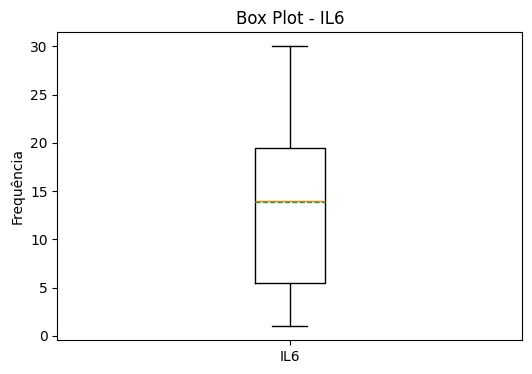

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def calcular_iqr(dados_unidimensionais):
  s = pd.Series(dados_unidimensionais)
  q1 = s.quantile(0.25)
  q3 = s.quantile(0.75)
  return q3 - q1

if 'E' not in df_novo.columns:
  df_novo['E'] = [15, 22, 30, 18, 25]

iqr_e = calcular_iqr(df_novo['E'])

penultimo_gene_dados = df_novo.iloc[-2]
iqr_penultimo_gene = calcular_iqr(penultimo_gene_dados)

print(f"IQR Ácido Glutâmico: {iqr_e}")
print(f"IQR Penúltimo Gene ({df_novo.index[-2]}): {iqr_penultimo_gene}")

plt.figure(figsize=(6, 4))
plt.boxplot(penultimo_gene_dados, showmeans=True, meanline=True)
plt.title(f"Box Plot - {df_novo.index[-2]}")
plt.ylabel("Frequência")
plt.xticks([1], [df_novo.index[-2]])
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [15]:
import pandas as pd

def calcular_variancia(dados_unidimensionais):
  s = pd.Series(dados_unidimensionais)
  return s.var()

if 'P' not in df_novo.columns:
  df_novo['P'] = [18, 12, 25, 30, 22]

variancia_prolina = calcular_variancia(df_novo['P'])

dados_terceiro_gene = df_novo.iloc[2]
variancia_terceiro_gene = calcular_variancia(dados_terceiro_gene)

print(f"Variância da Prolina (P): {variancia_prolina:.2f}")
print(f"Variância do terceiro gene ({df_novo.index[2]}): {variancia_terceiro_gene:.2f}")

Variância da Prolina (P): 46.80
Variância do terceiro gene (TP53): 245.95


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [16]:
import pandas as pd

def calcular_desvio_padrao(dados_unidimensionais):
  s = pd.Series(dados_unidimensionais)
  return s.std()

if 'W' not in df_novo.columns:
  df_novo['W'] = [2, 5, 1, 3, 4]

desvio_triptofano = calcular_desvio_padrao(df_novo['W'])

dados_ultimo_gene = df_novo.iloc[-1]
desvio_ultimo_gene = calcular_desvio_padrao(dados_ultimo_gene)

print(f"Desvio Padrão do Triptofano (W): {desvio_triptofano:.2f}")
print(f"Desvio Padrão do gene de index -1 ({df_novo.index[-1]}): {desvio_ultimo_gene:.2f}")

Desvio Padrão do Triptofano (W): 1.58
Desvio Padrão do gene de index -1 (GAPDH): 14.41


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [17]:
import pandas as pd

def calcular_cv(dados_unidimensionais):
    s = pd.Series(dados_unidimensionais)
    media = s.mean()
    desvio = s.std()
    if media == 0:
        return 0
    return (desvio / media) * 100

if 'L' not in df_novo.columns:
    df_novo['L'] = [45, 52, 60, 38, 55]

cv_leucina = calcular_cv(df_novo['L'])

dados_segundo_gene = df_novo.iloc[1]
cv_segundo_gene = calcular_cv(dados_segundo_gene)

print(f"CV da Leucina (L): {cv_leucina:.2f}%")
print(f"CV do gene de index 1 ({df_novo.index[1]}): {cv_segundo_gene:.2f}%")

CV da Leucina (L): 17.26%
CV do gene de index 1 (TNF): 79.03%


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [18]:
import pandas as pd

def calcular_medidas_resumo(dados_unidimensionais):
    s = pd.Series(dados_unidimensionais)

    resumo = {
        "Média": s.mean(),
        "Mediana": s.median(),
        "Variância": s.var(),
        "Desvio Padrão": s.std(),
        "Amplitude": s.max() - s.min(),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
        "CV (%)": (s.std() / s.mean()) * 100 if s.mean() != 0 else 0
    }

    return resumo

medidas_serina = calcular_medidas_resumo(df_novo['S'])
medidas_ultimo_gene = calcular_medidas_resumo(df_novo.iloc[-1])

print("--- Medidas Resumo: Serina ---")
print(medidas_serina)

print(f"\n--- Medidas Resumo: Gene {df_novo.index[-1]} ---")
print(medidas_ultimo_gene)

--- Medidas Resumo: Serina ---
{'Média': np.float64(15.4), 'Mediana': 15.0, 'Variância': 22.799999999999997, 'Desvio Padrão': 4.774934554525329, 'Amplitude': 12, 'IQR': np.float64(6.0), 'CV (%)': np.float64(31.006068535878757)}

--- Medidas Resumo: Gene GAPDH ---
{'Média': np.float64(23.444444444444443), 'Mediana': 22.0, 'Variância': 321.77777777777777, 'Desvio Padrão': 17.93816539609828, 'Amplitude': 52, 'IQR': np.float64(28.0), 'CV (%)': np.float64(76.51350168951873)}


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [ ]:
SIm, os dados concordam, pois no boxplot o gene com maior CV é aquele com maior desproporção visual entre os aminoácidos.

O gene com maior CV é o IFNG com 86.50%


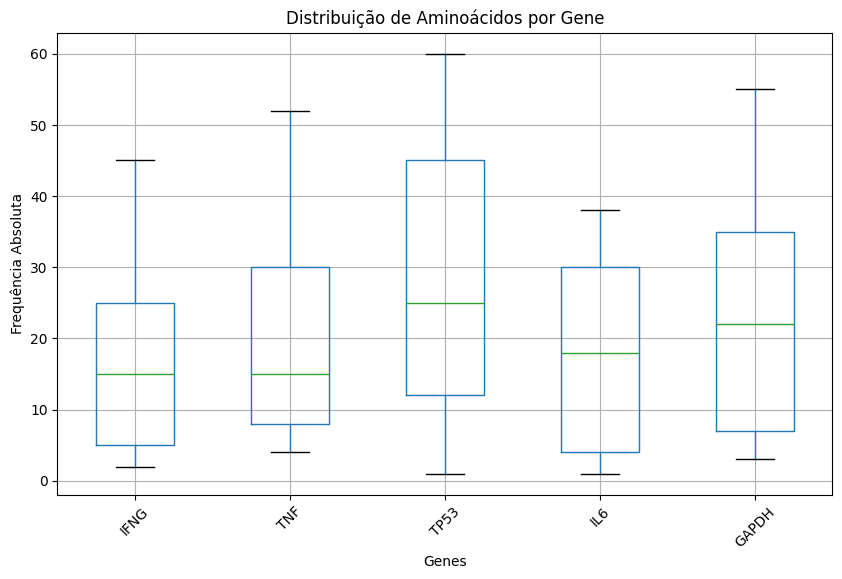

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

def gene_maior_cv(df):
    cvs = {}
    for i in range(len(df)):
        linha = df.iloc[i]
        media = linha.mean()
        desvio = linha.std()
        cv = (desvio / media) * 100 if media != 0 else 0
        cvs[df.index[i]] = cv

    gene_max = max(cvs, key=cvs.get)
    return gene_max, cvs[gene_max]

nome_gene, valor_cv = gene_maior_cv(df_novo)
print(f"O gene com maior CV é o {nome_gene} com {valor_cv:.2f}%")

plt.figure(figsize=(10, 6))
df_novo.T.boxplot()
plt.title("Distribuição de Aminoácidos por Gene")
plt.ylabel("Frequência Absoluta")
plt.xlabel("Genes")
plt.xticks(rotation=45)
plt.show()

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [ ]:
Sim os dados concordam, assim como no boxplot de cima, o aminoácido com maior CV é aquele com maior desproporção visual entre os genes.

O aminoácido com maior CV é o C com 75.05%


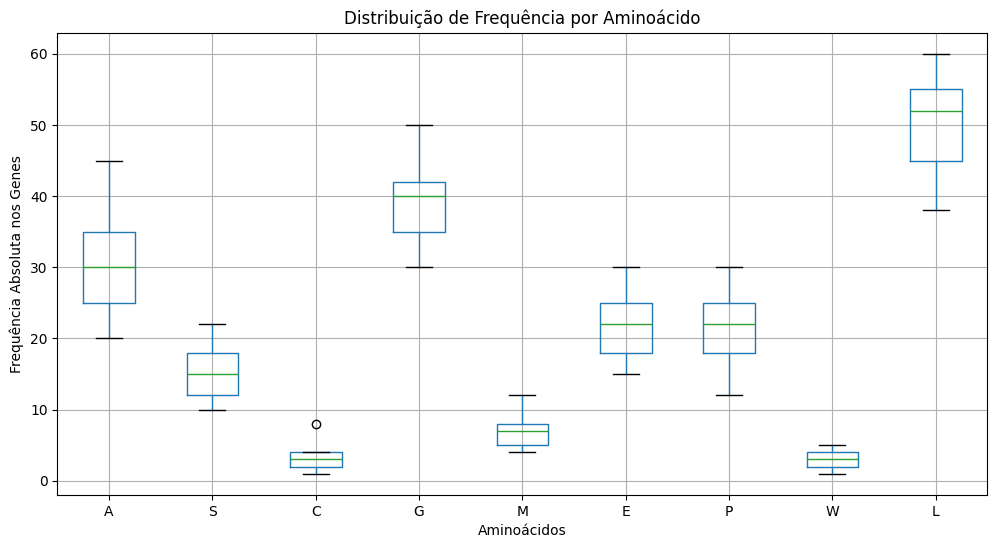

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

def aminoacido_maior_cv(df):
    cvs = {}
    for col in df.columns:
        coluna = df[col]
        media = coluna.mean()
        desvio = coluna.std()
        cv = (desvio / media) * 100 if media != 0 else 0
        cvs[col] = cv

    aa_max = max(cvs, key=cvs.get)
    return aa_max, cvs[aa_max]

nome_aa, valor_cv = aminoacido_maior_cv(df_novo)
print(f"O aminoácido com maior CV é o {nome_aa} com {valor_cv:.2f}%")

plt.figure(figsize=(12, 6))
df_novo.boxplot()
plt.title("Distribuição de Frequência por Aminoácido")
plt.ylabel("Frequência Absoluta nos Genes")
plt.xlabel("Aminoácidos")
plt.show()